# ANALYSIS OF BIBLIOGRAPHIC DATA

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# Helpers

In [12]:
def powerset_bit(iterable):
    s = list(iterable)
    return [subset for r in range(1, len(s) + 1)
            for subset in itertools.combinations(s, r)]
# Tests
powerset_bit("abc")

[('a',), ('b',), ('c',), ('a', 'b'), ('a', 'c'), ('b', 'c'), ('a', 'b', 'c')]

# Data access

In [4]:
path = "/Users/jlheller/home/Technical/repos/ModularitySurvey/axes/highly_relevant_axis_scores.csv"
FULL_DF = pd.read_csv(path)
SCORE_DF = FULL_DF[ ["trait_score", "network_score", "function_score"]]
SCORE_DF

,trait_score,network_score,function_score
0,0,90,30
1,0,10,80
2,0,90,0
3,0,80,40
4,0,70,30
...,...,...,...
204,0,30,50
205,0,10,100
206,0,20,70
207,60,20,30


# Coverage Plots

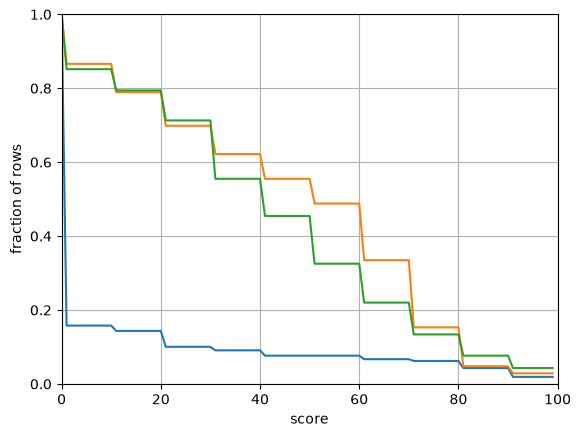

In [30]:
def plotCoverage(arr: np.ndarray):
    xv = []
    yv = []
    for x in range(100):
        xv.append(x)
        yv.append(np.sum(arr >= x) / len(arr))
    plt.plot(xv, yv)
    plt.xlim([0, 100])
    plt.ylim([0, 1])
    plt.xlabel("score")
    plt.ylabel("fraction of rows")
    plt.grid()

# Tests
plotCoverage(SCORE_DF["trait_score"])
plotCoverage(SCORE_DF["network_score"])
plotCoverage(SCORE_DF["function_score"])

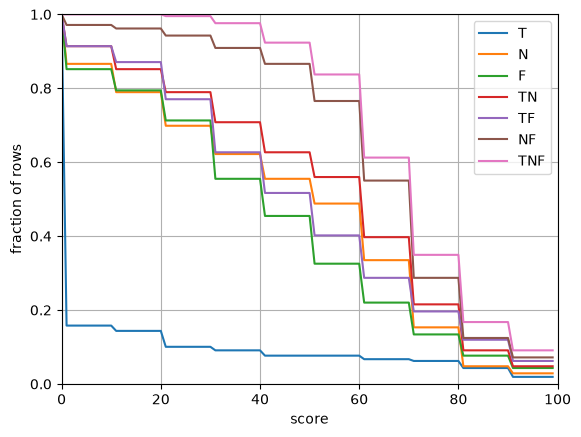

In [32]:
plotCoverage(SCORE_DF["trait_score"])
plotCoverage(SCORE_DF["network_score"])
plotCoverage(SCORE_DF["function_score"])
plotCoverage(np.maximum(SCORE_DF["trait_score"], SCORE_DF['network_score']))
plotCoverage(np.maximum(SCORE_DF["trait_score"], SCORE_DF['function_score']))
plotCoverage(np.maximum(SCORE_DF["function_score"], SCORE_DF['network_score']))
vec = np.maximum(SCORE_DF['trait_score'], SCORE_DF["function_score"])
vec = np.maximum(vec, SCORE_DF['network_score'])
plotCoverage(vec)
_ = plt.legend(["T", "N", "F", "TN", "TF", "NF", "TNF"])

# Correlation analysis

In [33]:
SCORE_DF.corr()

,trait_score,network_score,function_score
trait_score,1.000000,-0.350431,-0.320771
network_score,-0.350431,1.000000,-0.503380
function_score,-0.320771,-0.503380,1.000000
